**Hücre 1 — Kurulum, yapılandırma ve Drive**

Tüm kütüphaneleri kurar, sabitleri (seed, Pool=1000 / Test=150, model adları) tek yerde toplar ve çıktıların kaybolmaması için Google Drive'a kalıcı çalışma klasörü bağlar. hf_transfer ile model indirme hızlandırılır.

In [1]:
!pip install -q -U datasets sentence-transformers openai transformers accelerate hf_transfer

import os, json, re, time, pickle, random
os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "1"
import numpy as np, torch
from concurrent.futures import ThreadPoolExecutor, as_completed
from getpass import getpass

# --- Yapılandırma ---
SEED, N_POOL, N_TEST, K = 42, 1000, 150, 5
GEN_MODEL = "google/gemini-2.5-flash"          # OpenRouter slug (güncelse değiştir)
SOLVER    = "Qwen/Qwen2.5-3B-Instruct"
EMB_MODEL = "ytu-ce-cosmos/turkish-e5-large"
DEVICE    = "cuda" if torch.cuda.is_available() else "cpu"
print("Cihaz:", DEVICE, "|", torch.cuda.get_device_name(0) if DEVICE=="cuda" else "")

from google.colab import drive
drive.mount('/content/drive')
WORK = "/content/drive/MyDrive/gsm8k_icl"; os.makedirs(WORK, exist_ok=True)
print("Çalışma klasörü:", WORK)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 51.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 93.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 148.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 41.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 134.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 57.2 MB/s eta 0:00:00
Cihaz: cuda | NVIDIA A100-SXM4-40GB
Mounted at /content/drive
Çalışma klasörü: /content/drive/MyDrive/gsm8k_icl


**Hücre 2 — Veri yükleme ve cevap/tahmin çıkarımı**

gsm8k_tr'yi yükler. İki çıkarıcı tanımlar: extract_gold (dataset cevabından referans sayıyı katı kurallarla çeker; belirsiz/çok-cevaplıyı eler) ve extract_pred (modelin çıktısından önce "Sonuç:" etiketini, yoksa son sayıyı alır). Bu ayrım kritik: gold güvenilir olmalı, model çıktısı toleranslı okunmalı.

In [2]:
from datasets import load_dataset
ds = load_dataset("ytu-ce-cosmos/gsm8k_tr")["train"]
print("Toplam satır:", len(ds))
NUM_PAT = r"[-+]?\d[\d.,]*"

def to_float(tok):
    tok = tok.strip().rstrip(".,")
    if not tok: return None
    neg = tok.startswith("-"); tok = tok.lstrip("+-")
    m = re.search(r"[.,](\d{1,2})$", tok)
    if m:
        intpart = re.sub(r"[.,]", "", tok[:m.start()]) or "0"
        val = float(f"{intpart}.{m.group(1)}")
    else:
        s = re.sub(r"[.,]", "", tok); val = float(s) if s else None
    return (-val if neg else val) if val is not None else None

def extract_gold(answer):
    text = answer.strip()
    lines = [l for l in text.splitlines() if l.strip()]
    last = lines[-1] if lines else text
    if "=" in last:
        nums = re.findall(NUM_PAT, last.split("=")[-1])
        if nums: return to_float(nums[0]), "ok_eq"
    nums = re.findall(NUM_PAT, last)
    if len(nums) == 1:   return to_float(nums[0]), "ok_single"
    elif len(nums) > 1:  return to_float(nums[-1]), "ambiguous_multi"
    alln = re.findall(NUM_PAT, text)
    return (to_float(alln[-1]), "fallback") if alln else (None, "no_number")

def extract_pred(text):
    m = re.search(r"(?:Sonuç|Sonuc|Cevap|Yanıt)\s*[:=]\s*([-+]?\d[\d.,]*)", text, re.I)
    if m:
        v = to_float(m.group(1))
        if v is not None: return v
    return extract_gold(text)[0]

# Hızlı doğrulama
print("Örnek gold:", extract_gold(ds[50]["answer"]))
print("Örnek pred:", extract_pred("Adımlar... Böylece Sonuç: 48 olur."))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/constants.py:277: FutureWarning: The `HF_HUB_ENABLE_HF_TRANSFER` environment variable is deprecated as 'hf_transfer' is not used anymore. Please use `HF_XET_HIGH_PERFORMANCE` instead to enable high performance transfer with Xet. Visit https://huggingface.co/docs/huggingface_hub/package_reference/environment_variables#hfxethighperformance for more details.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/1.18k [00:00<?, ?B/s]

gsm8k_tr.csv:   0%|          | 0.00/5.02M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/8792 [00:00<?, ? examples/s]

Toplam satır: 8792
Örnek gold: (48.0, 'ok_single')
Örnek pred: 48.0


**Hücre 3 — Temiz havuz + Pool/Test bölmesi**

8792 örnekten extract_gold'un yüksek-güven (ok_eq/ok_single) işaretlediği temiz örnekleri süzer (~7528). Sabit seed ile çakışmasız 1000 pool + 150 test ayırır ve Drive'a kaydeder (split.pkl). Pool few-shot kaynağı, test doğruluk ölçülen kümedir.

In [3]:
SPLIT_PATH = os.path.join(WORK, "split.pkl")
if os.path.exists(SPLIT_PATH):
    sp = pickle.load(open(SPLIT_PATH, "rb")); pool_set, test_set = sp["pool"], sp["test"]
    print("Split Drive'dan yüklendi.")
else:
    clean_idx = []
    for i in range(len(ds)):
        v, s = extract_gold(ds[i]["answer"])
        if s in ("ok_eq","ok_single") and v is not None: clean_idx.append(i)
    print("Temiz örnek:", len(clean_idx))
    random.seed(SEED)
    picked = random.sample(clean_idx, N_POOL + N_TEST)
    test_idx, pool_idx = picked[:N_TEST], picked[N_TEST:]
    def build(idxs):
        out=[]
        for i in idxs:
            ex=ds[i]; g,_=extract_gold(ex["answer"])
            out.append({"idx":i,"question":ex["question"],"answer":ex["answer"],"gold":g})
        return out
    pool_set, test_set = build(pool_idx), build(test_idx)
    assert len(set(test_idx) & set(pool_idx)) == 0
    pickle.dump({"pool":pool_set,"test":test_set,"seed":SEED}, open(SPLIT_PATH,"wb"))
print(f"Pool {len(pool_set)} | Test {len(test_set)} | Kesişim 0 ✓")

Split Drive'dan yüklendi.
Pool 500 | Test 150 | Kesişim 0 ✓


**Hücre 4 — Prompt Optimizasyonu (1/4): opt-set + 3 prompt varyantı üretimi**

Test'ten ayrık küçük bir küme (40 dev sorusu + 150 mini-havuz) kurar ve 3 prompt varyantıyla (V1 düz, V2 örnekle kalibre, V3 yapı-soyutlama vurgulu) tarif üretir. Hepsi cache'li (prompt_opt_cache.json).

In [4]:
from openai import OpenAI
test_idx_set = {r["idx"] for r in test_set}
clean2 = [i for i in range(len(ds))
          if extract_gold(ds[i]["answer"])[1] in ("ok_eq","ok_single")
          and extract_gold(ds[i]["answer"])[0] is not None and i not in test_idx_set]
random.seed(7)
op = random.sample(clean2, 190); dev_idx, optpool_idx = op[:40], op[40:]
def rows(idxs):
    out=[]
    for i in idxs:
        ex=ds[i]; g,_=extract_gold(ex["answer"])
        out.append({"idx":i,"question":ex["question"],"answer":ex["answer"],"gold":g})
    return out
dev_set, optpool_set = rows(dev_idx), rows(optpool_idx)
print(f"opt dev {len(dev_set)} | mini-havuz {len(optpool_set)}")

CORE = ("Sen bir matematik problemi sınıflandırma uzmanısın. Türkçe problemi İÇERİĞİNDEN "
        "tamamen arındırarak SADECE TÜRÜNÜ tarif et. Somut sayı, isim, nesne, para birimi YAZMA.")
SCHEMA = ('SADECE şu JSON: {{"islem_yapisi":"kaç adım, hangi işlemler, kaç bilinmeyen — soyut",'
          '"problem_semasi":"senaryo arketipi — soyut","cozum_deseni":"akıl yürütme deseni — soyut"}}')
VARIANTS = {
 "v1": {"sys": CORE, "usr": "PROBLEM:\n{q}\n\n"+SCHEMA},
 "v2": {"sys": CORE+" Soyutlamayı tutarlı yap.",
        "usr": ("ÖRNEK — Problem: 'Ali 3 elma aldı, 2 tane daha aldı, kaç oldu?'  →  "
                '{{"islem_yapisi":"iki adımlı, tek işlem (toplama), tek bilinmeyen",'
                '"problem_semasi":"bir niceliğin ardışık artışı","cozum_deseni":"ardışık değerleri toplama"}}\n\n'
                "ŞİMDİ:\nPROBLEM:\n{q}\n\n"+SCHEMA)},
 "v3": {"sys": (CORE+" KURAL: Farklı senaryolu ama AYNI matematiksel yapıdaki iki problem "
                "neredeyse AYNI tarifi almalı. Önce yapıyı düşün, sonra senaryodan tamamen soyutla."),
        "usr": "PROBLEM:\n{q}\n\nÖnce zihninde yapıyı çöz, sonra "+SCHEMA},
}

PO_CACHE = os.path.join(WORK, "prompt_opt_cache.json")
pcache = json.load(open(PO_CACHE)) if os.path.exists(PO_CACHE) else {}
opt_rows = {r["idx"]: r for r in (dev_set+optpool_set)}
jobs = [(var,i) for var in VARIANTS for i in opt_rows if f"{var}:{i}" not in pcache]
if jobs:
    client = OpenAI(base_url="https://openrouter.ai/api/v1", api_key=getpass("OpenRouter key: "))
    def gen_v(var,q):
        v=VARIANTS[var]
        r=client.chat.completions.create(model=GEN_MODEL,temperature=0.2,
            messages=[{"role":"system","content":v["sys"]},{"role":"user","content":v["usr"].format(q=q)}])
        t=re.sub(r"^```(?:json)?|```$","",r.choices[0].message.content.strip(),flags=re.M).strip()
        return json.loads(t)
    def safe(job):
        var,i=job
        for a in range(4):
            try: return job, gen_v(var,opt_rows[i]["question"])
            except Exception as e:
                if a==3: return job,{"_error":str(e)}
                time.sleep(2*(a+1))
    print("Üretilecek:", len(jobs))
    with ThreadPoolExecutor(max_workers=8) as ex:
        for n,fut in enumerate(as_completed(ex.submit(safe,j) for j in jobs),1):
            (var,i),d=fut.result(); pcache[f"{var}:{i}"]=d
            if n%50==0: json.dump(pcache,open(PO_CACHE,"w"),ensure_ascii=False); print(f"  {n}/{len(jobs)}")
    json.dump(pcache,open(PO_CACHE,"w"),ensure_ascii=False)
print("Hata:", sum("_error" in v for v in pcache.values()))

opt dev 40 | mini-havuz 150
OpenRouter key: ··········
Üretilecek: 570
  50/570
  100/570
  150/570
  200/570
  250/570
  300/570
  350/570
  400/570
  450/570
  500/570
  550/570
Hata: 0


**Hücre 5 — Prompt Optimizasyonu (2/4): sızıntı oranı + retrieval tutarlılığı**

Sızıntı oranı: tarife somut içerik (rakam/para/özel isim) kaçmış mı (düşük = daha soyut).
Retrieval tutarlılığı: cevaplardan işlem-imzası {+,−,×,÷} çıkarıp, tarif-embedding'iyle çekilen 5 komşunun imzasının soruyla Jaccard örtüşmesi (yüksek = aynı yapıyı getiriyor).

In [5]:
from sentence_transformers import SentenceTransformer
if "em" not in globals(): em = SentenceTransformer(EMB_MODEL, device=DEVICE)
CUR = ("tl","lira","dolar","euro","avro","$","€","₺")
def names(q): return set(re.findall(r"\b[A-ZĞÜŞİÖÇ][a-zğüşıöç]+", q))
def leaked(dd,q):
    nm=names(q)
    for v in dd.values():
        sv=str(v)
        if re.search(r"\d",sv): return True
        if any(c in sv.lower() for c in CUR): return True
        if nm & set(re.findall(r"\b[A-ZĞÜŞİÖÇ][a-zğüşıöç]+",sv)): return True
    return False
def op_sig(a):
    a=a.lower().replace("×","*").replace(" x "," * "); s=set()
    if "+" in a: s.add("+")
    if re.search(r"\d\s*-\s*\d",a): s.add("-")
    if "*" in a: s.add("*")
    if "/" in a or "böl" in a: s.add("/")
    return s
def jacc(a,b): return len(a&b)/len(a|b) if (a|b) else 1.0
def vd(var,i,key): return pcache[f"{var}:{i}"].get(key,"")

po = {}
for var in VARIANTS:
    leak=np.mean([leaked(pcache[f"{var}:{r['idx']}"],r["question"]) for r in (dev_set+optpool_set)])
    qv=em.encode([f"query: {vd(var,r['idx'],'problem_semasi')}" for r in dev_set],
                 normalize_embeddings=True,convert_to_numpy=True)
    pv=em.encode([f"passage: {vd(var,r['idx'],'problem_semasi')}" for r in optpool_set],
                 normalize_embeddings=True,convert_to_numpy=True)
    top=np.argsort(-(qv@pv.T),axis=1)[:,:5]
    cons=np.mean([np.mean([jacc(op_sig(dev_set[i]["answer"]),op_sig(optpool_set[j]["answer"]))
                           for j in top[i]]) for i in range(len(dev_set))])
    po[var]={"sizinti":float(leak),"tutarlilik":float(cons)}
    print(f"{var}: sızıntı={leak:.1%}  tutarlılık={cons:.3f}")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/205 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.60k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

...

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

v1: sızıntı=23.7%  tutarlılık=0.405
v2: sızıntı=13.7%  tutarlılık=0.359
v3: sızıntı=27.9%  tutarlılık=0.358


**Hücre 6 — Prompt Optimizasyonu (3/4): mini-test doğruluğu (3B)**

En dürüst metrik: her varyantın tarifleriyle gerçekten 5-shot çözüp 40 dev sorusunda doğruluğa bakar. Çözücü model burada bir kez yüklenir ve sonraki çözüm hücresinde tekrar kullanılır.

In [6]:
from transformers import AutoModelForCausalLM, AutoTokenizer
if "model" not in globals():
    tok = AutoTokenizer.from_pretrained(SOLVER); tok.padding_side="left"
    model = AutoModelForCausalLM.from_pretrained(SOLVER, torch_dtype=torch.bfloat16, device_map=DEVICE).eval()
SYS = ("Sen matematik problemleri çözen bir asistansın. Adım adım çöz, cevabını en sonda "
       "'Sonuç: <sayı>' biçiminde tek sayı olarak yaz.")
def solve(qs, shots_list, B=20):
    pr=[]
    for q,sh in zip(qs,shots_list):
        m=[{"role":"system","content":SYS}]
        for s in sh: m+=[{"role":"user","content":f"Soru: {s['question']}"},
                         {"role":"assistant","content":s["answer"]}]
        m.append({"role":"user","content":f"Soru: {q}"})
        pr.append(tok.apply_chat_template(m,tokenize=False,add_generation_prompt=True))
    out=[]
    for s in range(0,len(pr),B):
        enc=tok(pr[s:s+B],return_tensors="pt",padding=True,truncation=True,max_length=3072).to(DEVICE)
        with torch.no_grad():
            g=model.generate(**enc,max_new_tokens=512,do_sample=False,pad_token_id=tok.eos_token_id)
        out+=[tok.decode(g[j][enc["input_ids"].shape[1]:],skip_special_tokens=True) for j in range(g.shape[0])]
    return out
for var in VARIANTS:
    qv=em.encode([f"query: {vd(var,r['idx'],'problem_semasi')}" for r in dev_set],
                 normalize_embeddings=True,convert_to_numpy=True)
    pv=em.encode([f"passage: {vd(var,r['idx'],'problem_semasi')}" for r in optpool_set],
                 normalize_embeddings=True,convert_to_numpy=True)
    top=np.argsort(-(qv@pv.T),axis=1)[:,:5]
    shots=[[optpool_set[j] for j in top[i]] for i in range(len(dev_set))]
    preds=solve([r["question"] for r in dev_set], shots)
    acc=np.mean([extract_pred(p) is not None and abs((extract_pred(p) or 1e9)-r["gold"])<1e-4
                 for p,r in zip(preds,dev_set)])
    po[var]["mini_acc"]=float(acc); print(f"{var}: mini-doğruluk={acc:.1%}")

config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/35.6k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

v1: mini-doğruluk=52.5%
v2: mini-doğruluk=55.0%
v3: mini-doğruluk=52.5%


**Hücre 7 — Prompt Optimizasyonu (4/4): karar tablosu + kazananı dondur**

Üç metriği bir tabloda toplar; mini-test doğruluğu birincil, eşitlikte yüksek tutarlılık / düşük sızıntı ayırıcıdır. Kazanan prompt'un sistem+kullanıcı şablonunu (FINAL_SYS/FINAL_USR) ve metrikleri Drive'a kaydeder

In [7]:
print(f"\n{'Varyant':<8}{'Mini-Acc':>9}{'Tutarlılık':>12}{'Sızıntı':>9}")
for var in VARIANTS:
    m=po[var]; print(f"{var:<8}{m['mini_acc']:>8.1%}{m['tutarlilik']:>12.3f}{m['sizinti']:>8.1%}")
winner=max(VARIANTS,key=lambda v:(po[v]["mini_acc"],po[v]["tutarlilik"],-po[v]["sizinti"]))
FINAL_SYS, FINAL_USR = VARIANTS[winner]["sys"], VARIANTS[winner]["usr"]
json.dump({"winner":winner,"metrics":po,"sys":FINAL_SYS,"usr":FINAL_USR},
          open(os.path.join(WORK,"prompt_choice.json"),"w"),ensure_ascii=False,indent=2)
print(f"\n>>> Kazanan prompt: {winner}")


Varyant  Mini-Acc  Tutarlılık  Sızıntı
v1         52.5%       0.405   23.7%
v2         55.0%       0.359   13.7%
v3         52.5%       0.358   27.9%

>>> Kazanan prompt: v2


**Hücre 8 — Kazanan prompt'la asıl tip-tarif üretimi (1150 örnek)**

Pool+Test'in tamamı için, kazanan prompt ile 3 soyut tarifi üretir. Cache kazanan etiketiyle adlandırılır (descriptions_cache_{winner}.json) ki farklı prompt çıktıları karışmasın. Sonra 4 temsili (ham soru + 3 tarif) her satıra ekler.

In [8]:
all_rows = {r["idx"]: r for r in (pool_set + test_set)}
MAIN_CACHE = os.path.join(WORK, f"descriptions_cache_{winner}.json")
cache = json.load(open(MAIN_CACHE)) if os.path.exists(MAIN_CACHE) else {}
todo = [i for i in all_rows if str(i) not in cache or "_error" in cache.get(str(i),{})]
if todo:
    client = OpenAI(base_url="https://openrouter.ai/api/v1", api_key=getpass("OpenRouter key: "))
    def gen_main(q):
        r=client.chat.completions.create(model=GEN_MODEL,temperature=0.2,
            messages=[{"role":"system","content":FINAL_SYS},{"role":"user","content":FINAL_USR.format(q=q)}])
        t=re.sub(r"^```(?:json)?|```$","",r.choices[0].message.content.strip(),flags=re.M).strip()
        return json.loads(t)
    def safe(i):
        for a in range(4):
            try: return i, gen_main(all_rows[i]["question"])
            except Exception as e:
                if a==3: return i,{"_error":str(e)}
                time.sleep(2*(a+1))
    print("Üretilecek:", len(todo))
    with ThreadPoolExecutor(max_workers=8) as ex:
        for n,fut in enumerate(as_completed(ex.submit(safe,i) for i in todo),1):
            i,d=fut.result(); cache[str(i)]=d
            if n%50==0: json.dump(cache,open(MAIN_CACHE,"w"),ensure_ascii=False); print(f"  {n}/{len(todo)}")
    json.dump(cache,open(MAIN_CACHE,"w"),ensure_ascii=False)
print("Hata:", sum("_error" in v for v in cache.values()))
for i,r in all_rows.items():
    d=cache[str(i)]
    r["repr_question"]=r["question"]; r["repr_islem"]=d.get("islem_yapisi","")
    r["repr_sema"]=d.get("problem_semasi",""); r["repr_desen"]=d.get("cozum_deseni","")
print("4 temsil eklendi.")

OpenRouter key: ··········
Üretilecek: 650
  50/650
  100/650
  150/650
  200/650
  250/650
  300/650
  350/650
  400/650
  450/650
  500/650
  550/650
  600/650
  650/650
Hata: 0
4 temsil eklendi.


**Hücre 9 — turkish-e5-large embedding (cache'li)**

4 temsili de E5 ile gömer; E5 kuralı gereği pool tarafı passage:, test tarafı query: önekli, vektörler L2-normalize. Sonuç embeddings.npz'e yazılır.

In [9]:
REPRS = ["repr_question","repr_islem","repr_sema","repr_desen"]
EMB_PATH = os.path.join(WORK, f"embeddings_{winner}.npz")
if os.path.exists(EMB_PATH):
    data = dict(np.load(EMB_PATH)); print("Embedding'ler yüklendi.")
else:
    def embed(texts,prefix):
        return em.encode([f"{prefix}{t}" for t in texts],batch_size=64,convert_to_numpy=True,
                         normalize_embeddings=True,show_progress_bar=True).astype(np.float32)
    data={}
    for rep in REPRS:
        data[f"pool_{rep}"]=embed([r[rep] for r in pool_set],"passage: ")
        data[f"test_{rep}"]=embed([r[rep] for r in test_set],"query: ")
        print(f"{rep}: pool {data[f'pool_{rep}'].shape}, test {data[f'test_{rep}'].shape}")
    np.savez(EMB_PATH,**data); print("Kaydedildi.")

Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Batches:   0%|          | 0/3 [00:00<?, ?it/s]

repr_question: pool (500, 1024), test (150, 1024)


Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Batches:   0%|          | 0/3 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/3 [00:00<?, ?it/s]

repr_sema: pool (500, 1024), test (150, 1024)


Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Batches:   0%|          | 0/3 [00:00<?, ?it/s]

repr_desen: pool (500, 1024), test (150, 1024)
Kaydedildi.


**Hücre 10 — Retrieval (her temsilde top-5 + rastgele baseline)**

Her test sorusu için her temsilde en benzer 5 pool örneğini seçer; rastgele baseline her soruya ayrı ve sabit seed'le çekilir. Sonunda sema komşularını rastgelelerle yan yana basıp niteliksel kontrol yapar.

In [10]:
conds = {"question":"repr_question","islem":"repr_islem","sema":"repr_sema","desen":"repr_desen"}
retrieved = {c:[] for c in conds}; retrieved["random"]=[]
for c,rep in conds.items():
    top=np.argsort(-(data[f"test_{rep}"]@data[f"pool_{rep}"].T),axis=1)[:,:K]
    for i in range(len(test_set)): retrieved[c].append([pool_set[j] for j in top[i]])
rng=np.random.default_rng(123)
for i in range(len(test_set)):
    retrieved["random"].append([pool_set[j] for j in rng.choice(len(pool_set),K,replace=False)])
print("Koşullar:", list(retrieved.keys()))
print("\nTEST:", test_set[0]["question"][:110])
print("sema komşuları:");  [print("  •",r["question"][:80]) for r in retrieved["sema"][0]]
print("rastgele:");        [print("  •",r["question"][:80]) for r in retrieved["random"][0]]

Koşullar: ['question', 'islem', 'sema', 'desen', 'random']

TEST: Percy haftada 5 gün okuldan önce 1 saat ve okuldan sonra 1 saat yüzüyor.  Hafta sonları 3 saat yüzüyor.  Dört 
sema komşuları:
  • Jerry'nin iki kızı farklı takımlarda softbol oynuyor. Her birinin bu sezon 8 maç
  • Mark ekmek pişiriyor. İki kez 120 dakika kabarmasını beklemesi gerekiyor. Ayrıca
  • Her 10 saniyede bir araba çarpışıyor ve her 20 saniyede bir büyük bir kaza oluyo
  • Tom her gün 5 adet 12 onsluk kutu soda ve 64 ons su içiyor. Haftada kaç ons sıvı
  • Alaska Malamutu Toby, kızak yüksüzken saatte 20 mil hızla bir kızağı çekebilir, 
rastgele:
  • Mahkemenin zorunlu kıldığı bir trafik sınıfında, belirli sayıda sarhoş sürücü ve
  • Hermione, Luna ve Celestia'nın toplam 83 heceleme rozeti var. Hermione'nin 14 ve
  • Eğer Mark 150 kilo ve Susan Mark'tan 20 kilo daha hafifse.  Arkadaşları Bob ise 
  • Bill ailesinin kahvaltısı için omlet yapıyor. Bir biberi doğraması 3 dakika, bir
  • Kenny geçen hafta 10 saat ba

[None, None, None, None, None]

**Hücre 11 — Çözüm: 6 koşulu 3B ile çöz**

Zero-shot + rastgele-5 + 4 temsil olmak üzere 6 koşulu 150 test sorusunda greedy decoding ile çözer, extract_pred ile değerlendirir, doğrulukları ve ham çıktıları Drive'a yazar.

In [11]:
all_conditions = {"zero_shot":[[] for _ in test_set]}
for c in ["random","question","islem","sema","desen"]: all_conditions[c]=retrieved[c]
def accuracy(preds):
    c=0
    for r,p in zip(test_set,preds):
        v=extract_pred(p)
        if v is not None and abs(v-r["gold"])<1e-4: c+=1
    return c/len(test_set)
results, raw = {}, {}
for name,shots in all_conditions.items():
    print(f"\n[{name}] çözülüyor...")
    preds=solve([r["question"] for r in test_set], shots, B=16)
    results[name]=accuracy(preds); raw[name]=preds
    print(f"[{name}] doğruluk: {results[name]:.1%}")
json.dump(results,open(os.path.join(WORK,"results.json"),"w"),indent=2)
json.dump(raw,open(os.path.join(WORK,"raw_preds.json"),"w"),ensure_ascii=False)


[zero_shot] çözülüyor...
[zero_shot] doğruluk: 44.0%

[random] çözülüyor...
[random] doğruluk: 46.0%

[question] çözülüyor...
[question] doğruluk: 46.0%

[islem] çözülüyor...
[islem] doğruluk: 48.7%

[sema] çözülüyor...
[sema] doğruluk: 41.3%

[desen] çözülüyor...
[desen] doğruluk: 45.3%


Hücre 12 — Sonuç tablosu, grafik ve şart kontrolü

6 koşulu Türkçe etiketlerle tablo+bar grafik olarak basar, kazanan temsili vurgular ve 5-shot > zero-shot; en iyi ≥%30 işaretler. "Hangi tür metinle benzer bulmak daha başarılı" sorusunun cevabı buradaki en yüksek çubuktur.


Koşul             Doğruluk
----------------------------
Zero-shot           44.0%
Rastgele-5          46.0%
Ham soru            46.0%
İşlem yapısı        48.7%
Problem şeması      41.3%
Çözüm deseni        45.3%
----------------------------
En iyi 5-shot: İşlem yapısı (48.7%)
Şart 1 (5-shot>zero): ✓
Şart 2 (≥%30):        ✓


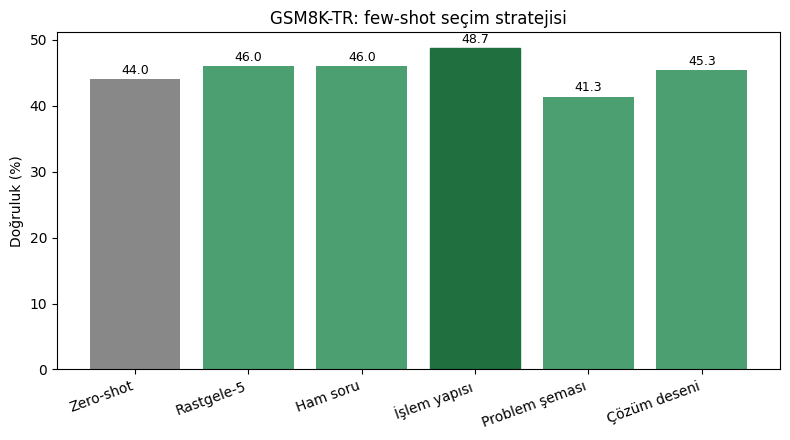

In [12]:
import matplotlib.pyplot as plt
LABELS={"zero_shot":"Zero-shot","random":"Rastgele-5","question":"Ham soru",
        "islem":"İşlem yapısı","sema":"Problem şeması","desen":"Çözüm deseni"}
order=["zero_shot","random","question","islem","sema","desen"]
print(f"\n{'Koşul':<18}{'Doğruluk':>8}\n"+"-"*28)
for k in order: print(f"{LABELS[k]:<18}{results[k]:>7.1%}")
best5=max([k for k in order if k!='zero_shot'], key=lambda k:results[k])
print("-"*28)
print(f"En iyi 5-shot: {LABELS[best5]} ({results[best5]:.1%})")
print(f"Şart 1 (5-shot>zero): {'✓' if results[best5]>results['zero_shot'] else '✗'}")
print(f"Şart 2 (≥%30):        {'✓' if results[best5]>=0.30 else '✗'}")
vals=[results[k]*100 for k in order]
plt.figure(figsize=(8,4.5))
bars=plt.bar([LABELS[k] for k in order], vals, color=["#888"]+["#4C9F70"]*5)
bars[order.index(best5)].set_color("#1f6f3f")
for b,v in zip(bars,vals): plt.text(b.get_x()+b.get_width()/2,v+0.8,f"{v:.1f}",ha="center",fontsize=9)
plt.ylabel("Doğruluk (%)"); plt.title("GSM8K-TR: few-shot seçim stratejisi")
plt.xticks(rotation=20,ha="right"); plt.tight_layout()
plt.savefig(os.path.join(WORK,"sonuclar.png"),dpi=150); plt.show()

Bu sonuçlara göre "Benzer örnek rastgeleyi yener" iddiasını bu haliyle güçlü savunamayız.

**Hücre 13 — İstatistiksel anlamlılık (hata çubukları + McNemar)**

Her koşulun 95% güven aralığını hata çubuğuyla çizer ve kritik çiftler arasında (işlem↔rastgele, işlem↔zero, şema↔rastgele) eşleştirilmiş McNemar testi yapar. Farkların gürültü mü gerçek mi olduğunu söyler.

Eşleştirilmiş McNemar testleri:
  islem     vs random   : islem+19 / random+15  p=0.608  → anlamsız (gürültü)
  islem     vs zero_shot: islem+21 / zero_shot+13  p=0.229  → anlamsız (gürültü)
  sema      vs random   : sema+15 / random+22  p=0.324  → anlamsız (gürültü)
  question  vs random   : question+19 / random+19  p=1.000  → anlamsız (gürültü)


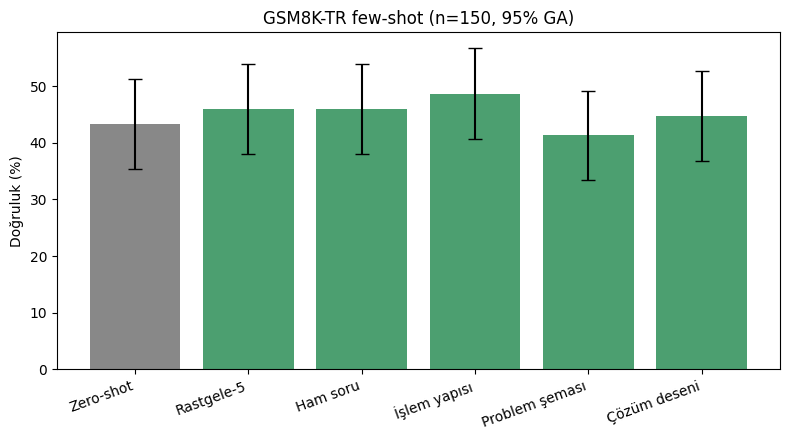

In [13]:
from scipy.stats import binomtest
import matplotlib.pyplot as plt, numpy as np

def correctness(preds):
    return [1 if (extract_pred(p) is not None and abs((extract_pred(p) or 1e9)-r["gold"])<1e-4) else 0
            for p,r in zip(preds, test_set)]
corr = {k: correctness(raw[k]) for k in raw}
n = len(test_set)

def mcnemar(a, b):
    b_only = sum(1 for x,y in zip(corr[a],corr[b]) if x and not y)   # a doğru, b yanlış
    c_only = sum(1 for x,y in zip(corr[a],corr[b]) if y and not x)   # b doğru, a yanlış
    tot = b_only + c_only
    p = binomtest(b_only, tot, 0.5).pvalue if tot>0 else 1.0
    return b_only, c_only, p

pairs = [("islem","random"),("islem","zero_shot"),("sema","random"),("question","random")]
print("Eşleştirilmiş McNemar testleri:")
for a,b in pairs:
    bo,co,p = mcnemar(a,b)
    sig = "ANLAMLI" if p<0.05 else "anlamsız (gürültü)"
    print(f"  {a:9} vs {b:9}: {a}+{bo} / {b}+{co}  p={p:.3f}  → {sig}")

# Hata çubuklu grafik (95% normal yaklaşım)
LABELS={"zero_shot":"Zero-shot","random":"Rastgele-5","question":"Ham soru",
        "islem":"İşlem yapısı","sema":"Problem şeması","desen":"Çözüm deseni"}
order=["zero_shot","random","question","islem","sema","desen"]
p_=np.array([np.mean(corr[k]) for k in order]); se=np.sqrt(p_*(1-p_)/n); ci=1.96*se
plt.figure(figsize=(8,4.5))
plt.bar([LABELS[k] for k in order], p_*100, yerr=ci*100, capsize=5,
        color=["#888"]+["#4C9F70"]*5)
plt.ylabel("Doğruluk (%)"); plt.title(f"GSM8K-TR few-shot (n={n}, 95% GA)")
plt.xticks(rotation=20,ha="right"); plt.tight_layout(); plt.show()

Cachei temizle

In [14]:
import os
for f in ["split.pkl", f"embeddings_{winner}.npz"]:
    p = os.path.join(WORK, f)
    if os.path.exists(p): os.remove(p); print("silindi:", f)

silindi: split.pkl
silindi: embeddings_v2.npz


**Hücre 15 — Büyütülmüş split (Pool 1000 / Test 300), opt-set'ten arındırılmış**

Yeni ölçeği kurar.
Bir incelik: yeni test/pool'u, prompt optimizasyonunda kullanılan opt-set'ten (dev+mini-havuz) dışlar — böylece nihai test, prompt seçim aşamasını hiç görmemiş olur (sızıntı yok). Kazanan prompt oturumda yoksa diskten geri yükler.

In [15]:
N_POOL, N_TEST, SEED_BIG = 1000, 300, 42

if "winner" not in globals():
    pc = json.load(open(os.path.join(WORK,"prompt_choice.json")))
    winner, FINAL_SYS, FINAL_USR = pc["winner"], pc["sys"], pc["usr"]
    print("prompt_choice diskten yüklendi → kazanan:", winner)

# Opt-set'i dışla (prompt optimizasyonunda kullanılan örnekler test'e sızmasın)
exclude = set()
if "dev_set" in globals():     exclude |= {r["idx"] for r in dev_set}
if "optpool_set" in globals(): exclude |= {r["idx"] for r in optpool_set}

clean_idx = [i for i in range(len(ds))
             if extract_gold(ds[i]["answer"])[1] in ("ok_eq","ok_single")
             and extract_gold(ds[i]["answer"])[0] is not None and i not in exclude]
print(f"Uygun temiz örnek (opt-set hariç): {len(clean_idx)}")

random.seed(SEED_BIG)
picked = random.sample(clean_idx, N_POOL+N_TEST)
test_idx, pool_idx = picked[:N_TEST], picked[N_TEST:]
def build(idxs):
    out=[]
    for i in idxs:
        ex=ds[i]; g,_=extract_gold(ex["answer"])
        out.append({"idx":i,"question":ex["question"],"answer":ex["answer"],"gold":g})
    return out
pool_set, test_set = build(pool_idx), build(test_idx)
assert len(set(test_idx)&set(pool_idx))==0
pickle.dump({"pool":pool_set,"test":test_set,"seed":SEED_BIG}, open(os.path.join(WORK,"split.pkl"),"wb"))
print(f"YENİ split → Pool {len(pool_set)} | Test {len(test_set)} | Kesişim 0 ✓")

Uygun temiz örnek (opt-set hariç): 7338
YENİ split → Pool 1000 | Test 300 | Kesişim 0 ✓


**Hücre 16 — Yeni split için tip-tarif üretimi (kazanan v2 prompt, mevcut cache'e ekleme)**

Yeni 1300 örneğin tariflerini kazanan prompt'la üretir. Eski v2 cache'inde olan örnekler atlanır, sadece yeni olanlar üretilir. Sonra 4 temsili satırlara ekler.

In [16]:
all_rows = {r["idx"]: r for r in (pool_set+test_set)}
MAIN_CACHE = os.path.join(WORK, f"descriptions_cache_{winner}.json")
cache = json.load(open(MAIN_CACHE)) if os.path.exists(MAIN_CACHE) else {}
todo = [i for i in all_rows if str(i) not in cache or "_error" in cache.get(str(i),{})]
print("Yeni üretilecek tarif:", len(todo))
if todo:
    from openai import OpenAI
    client = OpenAI(base_url="https://openrouter.ai/api/v1", api_key=getpass("OpenRouter key: "))
    def gen_main(q):
        r=client.chat.completions.create(model=GEN_MODEL,temperature=0.2,
            messages=[{"role":"system","content":FINAL_SYS},{"role":"user","content":FINAL_USR.format(q=q)}])
        t=re.sub(r"^```(?:json)?|```$","",r.choices[0].message.content.strip(),flags=re.M).strip()
        return json.loads(t)
    def safe(i):
        for a in range(4):
            try: return i, gen_main(all_rows[i]["question"])
            except Exception as e:
                if a==3: return i,{"_error":str(e)}
                time.sleep(2*(a+1))
    with ThreadPoolExecutor(max_workers=8) as ex:
        for n,fut in enumerate(as_completed(ex.submit(safe,i) for i in todo),1):
            i,d=fut.result(); cache[str(i)]=d
            if n%50==0: json.dump(cache,open(MAIN_CACHE,"w"),ensure_ascii=False); print(f"  {n}/{len(todo)}")
    json.dump(cache,open(MAIN_CACHE,"w"),ensure_ascii=False)
print("Hata:", sum("_error" in v for v in cache.values()))
for i,r in all_rows.items():
    d=cache[str(i)]
    r["repr_question"]=r["question"]; r["repr_islem"]=d.get("islem_yapisi","")
    r["repr_sema"]=d.get("problem_semasi",""); r["repr_desen"]=d.get("cozum_deseni","")
print("4 temsil eklendi.")

Yeni üretilecek tarif: 1178
OpenRouter key: ··········
  50/1178
  100/1178
  150/1178
  200/1178
  250/1178
  300/1178
  350/1178
  400/1178
  450/1178
  500/1178
  550/1178
  600/1178
  650/1178
  700/1178
  750/1178
  800/1178
  850/1178
  900/1178
  950/1178
  1000/1178
  1050/1178
  1100/1178
  1150/1178
Hata: 0
4 temsil eklendi.


**Hücre 17 — Embedding (yeni 1000/300 için, e5)**

Dört temsili yeniden gömer (eski .npz silindi). pool=passage:, test=query:, L2-normalize. em oturumda yoksa yükler.

In [17]:
REPRS = ["repr_question","repr_islem","repr_sema","repr_desen"]
EMB_PATH = os.path.join(WORK, f"embeddings_{winner}.npz")
if "em" not in globals():
    from sentence_transformers import SentenceTransformer
    em = SentenceTransformer(EMB_MODEL, device=DEVICE)
if os.path.exists(EMB_PATH):
    data = dict(np.load(EMB_PATH)); print("Embedding'ler yüklendi.")
else:
    def embed(texts,prefix):
        return em.encode([f"{prefix}{t}" for t in texts],batch_size=64,convert_to_numpy=True,
                         normalize_embeddings=True,show_progress_bar=True).astype(np.float32)
    data={}
    for rep in REPRS:
        data[f"pool_{rep}"]=embed([r[rep] for r in pool_set],"passage: ")
        data[f"test_{rep}"]=embed([r[rep] for r in test_set],"query: ")
        print(f"{rep}: pool {data[f'pool_{rep}'].shape}, test {data[f'test_{rep}'].shape}")
    np.savez(EMB_PATH,**data); print("Kaydedildi.")

Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

repr_question: pool (1000, 1024), test (300, 1024)


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

repr_sema: pool (1000, 1024), test (300, 1024)


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

repr_desen: pool (1000, 1024), test (300, 1024)
Kaydedildi.


**Hücre 18 — Retrieval (top-5 + rastgele, n=300)**

Her temsilde test→pool top-5; rastgele baseline sabit seed'le.

In [18]:
conds = {"question":"repr_question","islem":"repr_islem","sema":"repr_sema","desen":"repr_desen"}
retrieved = {c:[] for c in conds}; retrieved["random"]=[]
for c,rep in conds.items():
    top=np.argsort(-(data[f"test_{rep}"]@data[f"pool_{rep}"].T),axis=1)[:,:K]
    for i in range(len(test_set)): retrieved[c].append([pool_set[j] for j in top[i]])
rng=np.random.default_rng(123)
for i in range(len(test_set)):
    retrieved["random"].append([pool_set[j] for j in rng.choice(len(pool_set),K,replace=False)])
print("Koşullar:", list(retrieved.keys()), "| test", len(test_set), "| pool", len(pool_set))

Koşullar: ['question', 'islem', 'sema', 'desen', 'random'] | test 300 | pool 1000


Hücre 19 — Çözüm: 6 koşul × 300 soru (3B)

In [19]:
all_conditions = {"zero_shot":[[] for _ in test_set]}
for c in ["random","question","islem","sema","desen"]: all_conditions[c]=retrieved[c]
def accuracy(preds):
    c=0
    for r,p in zip(test_set,preds):
        v=extract_pred(p)
        if v is not None and abs(v-r["gold"])<1e-4: c+=1
    return c/len(test_set)
results, raw = {}, {}
for name,shots in all_conditions.items():
    print(f"[{name}] çözülüyor...")
    preds=solve([r["question"] for r in test_set], shots, B=16)
    results[name]=accuracy(preds); raw[name]=preds
    print(f"  doğruluk: {results[name]:.1%}")
json.dump(results,open(os.path.join(WORK,"results_n300.json"),"w"),indent=2)
json.dump(raw,open(os.path.join(WORK,"raw_preds_n300.json"),"w"),ensure_ascii=False)
print("Kaydedildi.")

[zero_shot] çözülüyor...
  doğruluk: 43.0%
[random] çözülüyor...
  doğruluk: 46.3%
[question] çözülüyor...
  doğruluk: 47.0%
[islem] çözülüyor...
  doğruluk: 46.0%
[sema] çözülüyor...
  doğruluk: 49.0%
[desen] çözülüyor...
  doğruluk: 45.3%
Kaydedildi.


**Hücre 20 — Tablo + grafik + şart kontrolü (n=300)**


Koşul             Doğruluk
----------------------------
Zero-shot           43.0%
Rastgele-5          46.3%
Ham soru            47.0%
İşlem yapısı        46.0%
Problem şeması      49.0%
Çözüm deseni        45.3%
----------------------------
En iyi 5-shot: Problem şeması (49.0%)
Şart 1 (5-shot>zero): ✓
Şart 2 (≥%30):        ✓


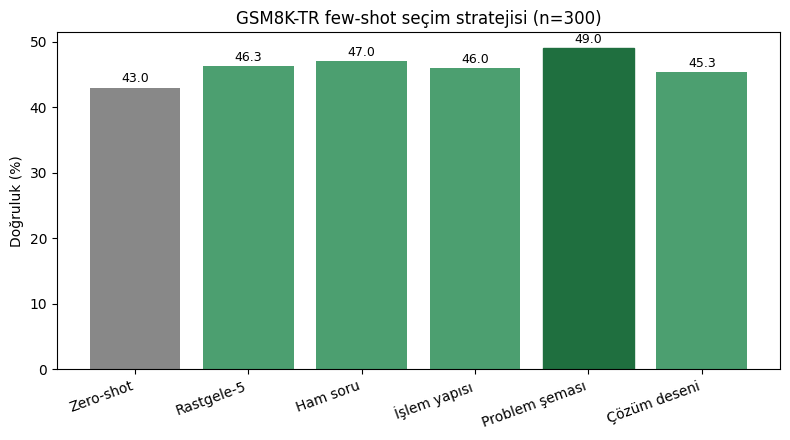

In [20]:
import matplotlib.pyplot as plt
LABELS={"zero_shot":"Zero-shot","random":"Rastgele-5","question":"Ham soru",
        "islem":"İşlem yapısı","sema":"Problem şeması","desen":"Çözüm deseni"}
order=["zero_shot","random","question","islem","sema","desen"]
print(f"\n{'Koşul':<18}{'Doğruluk':>8}\n"+"-"*28)
for k in order: print(f"{LABELS[k]:<18}{results[k]:>7.1%}")
best5=max([k for k in order if k!='zero_shot'], key=lambda k:results[k])
print("-"*28)
print(f"En iyi 5-shot: {LABELS[best5]} ({results[best5]:.1%})")
print(f"Şart 1 (5-shot>zero): {'✓' if results[best5]>results['zero_shot'] else '✗'}")
print(f"Şart 2 (≥%30):        {'✓' if results[best5]>=0.30 else '✗'}")
vals=[results[k]*100 for k in order]
plt.figure(figsize=(8,4.5))
bars=plt.bar([LABELS[k] for k in order], vals, color=["#888"]+["#4C9F70"]*5)
bars[order.index(best5)].set_color("#1f6f3f")
for b,v in zip(bars,vals): plt.text(b.get_x()+b.get_width()/2,v+0.8,f"{v:.1f}",ha="center",fontsize=9)
plt.ylabel("Doğruluk (%)"); plt.title("GSM8K-TR few-shot seçim stratejisi (n=300)")
plt.xticks(rotation=20,ha="right"); plt.tight_layout()
plt.savefig(os.path.join(WORK,"sonuclar_n300.png"),dpi=150); plt.show()

**Hücre 21 — İstatistiksel anlamlılık (hata çubukları + McNemar, n=300)**

Hücre-13'ün aynısı, yeni sonuçlar üzerinde. n=300'de güven aralığı daralacak; farkların artık anlamlı çıkıp çıkmadığını burada göreceğiz.

Eşleştirilmiş McNemar (n=300):
  islem     vs random   : islem+29 / random+30  p=1.000  → anlamsız
  islem     vs zero_shot: islem+42 / zero_shot+33  p=0.356  → anlamsız
  desen     vs random   : desen+29 / random+32  p=0.798  → anlamsız
  question  vs random   : question+33 / random+31  p=0.901  → anlamsız
  sema      vs random   : sema+32 / random+24  p=0.350  → anlamsız


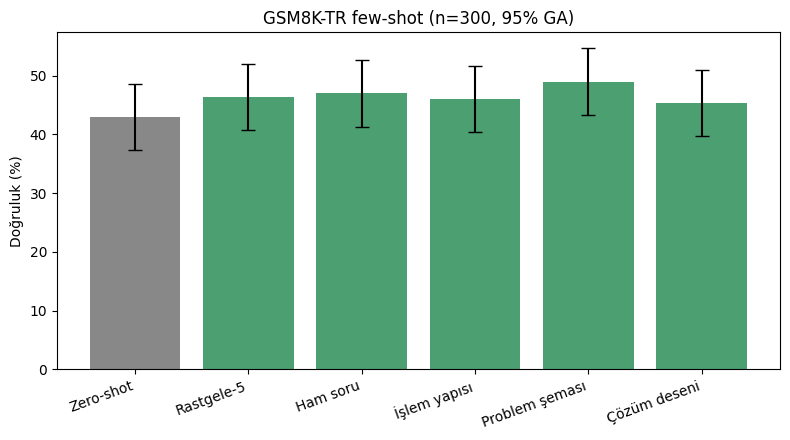

In [21]:
from scipy.stats import binomtest
def correctness(preds):
    return [1 if (extract_pred(p) is not None and abs((extract_pred(p) or 1e9)-r["gold"])<1e-4) else 0
            for p,r in zip(preds, test_set)]
corr = {k: correctness(raw[k]) for k in raw}; n=len(test_set)
def mcnemar(a,b):
    bo=sum(1 for x,y in zip(corr[a],corr[b]) if x and not y)
    co=sum(1 for x,y in zip(corr[a],corr[b]) if y and not x)
    p=binomtest(bo,bo+co,0.5).pvalue if (bo+co)>0 else 1.0
    return bo,co,p
print("Eşleştirilmiş McNemar (n=%d):"%n)
for a,b in [("islem","random"),("islem","zero_shot"),("desen","random"),
            ("question","random"),("sema","random")]:
    bo,co,p=mcnemar(a,b)
    print(f"  {a:9} vs {b:9}: {a}+{bo} / {b}+{co}  p={p:.3f}  → {'ANLAMLI' if p<0.05 else 'anlamsız'}")
p_=np.array([np.mean(corr[k]) for k in order]); ci=1.96*np.sqrt(p_*(1-p_)/n)
plt.figure(figsize=(8,4.5))
plt.bar([LABELS[k] for k in order], p_*100, yerr=ci*100, capsize=5, color=["#888"]+["#4C9F70"]*5)
plt.ylabel("Doğruluk (%)"); plt.title(f"GSM8K-TR few-shot (n={n}, 95% GA)")
plt.xticks(rotation=20,ha="right"); plt.tight_layout(); plt.show()

**Hücre 22 — Çözücüyü Qwen2.5-1.5B-Instruct ile değiştir**

3B'yi bellekten atıp 1.5B yükler. solve global model/tok kullandığı için, bunları yeniden atayınca otomatik 1.5B'ye geçer; başka hiçbir şeyi değiştirmeye gerek yok.

In [22]:
import torch, gc
from transformers import AutoModelForCausalLM, AutoTokenizer

# 3B'yi bellekten boşalt
try:
    del model
except: pass
gc.collect(); torch.cuda.empty_cache()

SOLVER_WEAK = "Qwen/Qwen2.5-1.5B-Instruct"
tok = AutoTokenizer.from_pretrained(SOLVER_WEAK); tok.padding_side = "left"
model = AutoModelForCausalLM.from_pretrained(SOLVER_WEAK, torch_dtype=torch.bfloat16,
                                             device_map=DEVICE).eval()
print("Yeni çözücü:", SOLVER_WEAK)

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Yeni çözücü: Qwen/Qwen2.5-1.5B-Instruct


**Hücre 23 — 6 koşulu 1.5B ile çöz (mevcut retrieval'i yeniden kullan)**

Hücre-18'deki retrieved (n=300) ve test_set oturumda hazır. Sadece çözüm tekrar koşuyor. Sonuçlar ayrı dosyaya (*_1p5b.json).

In [23]:
all_conditions = {"zero_shot":[[] for _ in test_set]}
for c in ["random","question","islem","sema","desen"]: all_conditions[c]=retrieved[c]
def accuracy(preds):
    return sum(1 for r,p in zip(test_set,preds)
               if (extract_pred(p) is not None and abs(extract_pred(p)-r["gold"])<1e-4))/len(test_set)
results, raw = {}, {}
for name,shots in all_conditions.items():
    print(f"[{name}] çözülüyor...")
    preds=solve([r["question"] for r in test_set], shots, B=24)
    results[name]=accuracy(preds); raw[name]=preds
    print(f"  doğruluk: {results[name]:.1%}")
json.dump(results,open(os.path.join(WORK,"results_1p5b.json"),"w"),indent=2)
json.dump(raw,open(os.path.join(WORK,"raw_preds_1p5b.json"),"w"),ensure_ascii=False)

[zero_shot] çözülüyor...
  doğruluk: 25.0%
[random] çözülüyor...
  doğruluk: 21.3%
[question] çözülüyor...
  doğruluk: 22.3%
[islem] çözülüyor...
  doğruluk: 22.0%
[sema] çözülüyor...
  doğruluk: 23.0%
[desen] çözülüyor...
  doğruluk: 23.3%


**Hücre 24 — Tablo + grafik + McNemar (1.5B)**

Hücre 20+21'in birleşik hali, 1.5B sonuçlarında. ≥%30 şartını burada da kontrol et — 1.5B düşük çıkarsa görürüz.



Koşul             Doğruluk
----------------------------
Zero-shot           25.0%
Rastgele-5          21.3%
Ham soru            22.3%
İşlem yapısı        22.0%
Problem şeması      23.0%
Çözüm deseni        23.3%
----------------------------
En iyi 5-shot: Çözüm deseni (23.3%)
Şart 1 (5-shot>zero): ✗
Şart 2 (≥%30):        ✗

McNemar (n=300):
  islem     vs random   : 31/29  p=0.897  → anlamsız
  sema      vs random   : 29/24  p=0.583  → anlamsız
  desen     vs random   : 32/26  p=0.512  → anlamsız
  question  vs random   : 27/24  p=0.780  → anlamsız
  desen     vs zero_shot: 25/30  p=0.590  → anlamsız


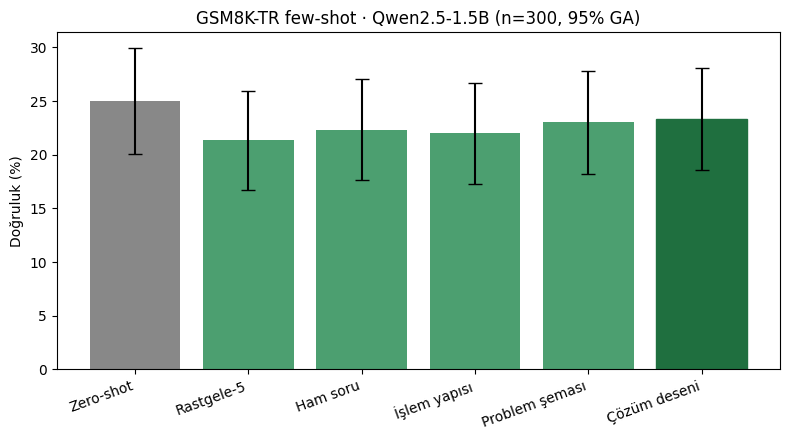

In [24]:
import matplotlib.pyplot as plt
from scipy.stats import binomtest
LABELS={"zero_shot":"Zero-shot","random":"Rastgele-5","question":"Ham soru",
        "islem":"İşlem yapısı","sema":"Problem şeması","desen":"Çözüm deseni"}
order=["zero_shot","random","question","islem","sema","desen"]
print(f"{'Koşul':<18}{'Doğruluk':>8}\n"+"-"*28)
for k in order: print(f"{LABELS[k]:<18}{results[k]:>7.1%}")
best5=max([k for k in order if k!='zero_shot'], key=lambda k:results[k])
print("-"*28); print(f"En iyi 5-shot: {LABELS[best5]} ({results[best5]:.1%})")
print(f"Şart 1 (5-shot>zero): {'✓' if results[best5]>results['zero_shot'] else '✗'}")
print(f"Şart 2 (≥%30):        {'✓' if results[best5]>=0.30 else '✗'}")

def correctness(preds):
    return [1 if (extract_pred(p) is not None and abs((extract_pred(p) or 1e9)-r["gold"])<1e-4) else 0
            for p,r in zip(preds,test_set)]
corr={k:correctness(raw[k]) for k in raw}; n=len(test_set)
def mcnemar(a,b):
    bo=sum(1 for x,y in zip(corr[a],corr[b]) if x and not y)
    co=sum(1 for x,y in zip(corr[a],corr[b]) if y and not x)
    return bo,co,(binomtest(bo,bo+co,0.5).pvalue if (bo+co)>0 else 1.0)
print(f"\nMcNemar (n={n}):")
for a,b in [("islem","random"),("sema","random"),("desen","random"),
            ("question","random"),(best5,"zero_shot")]:
    bo,co,p=mcnemar(a,b)
    print(f"  {a:9} vs {b:9}: {bo}/{co}  p={p:.3f}  → {'ANLAMLI' if p<0.05 else 'anlamsız'}")

p_=np.array([np.mean(corr[k]) for k in order]); ci=1.96*np.sqrt(p_*(1-p_)/n)
plt.figure(figsize=(8,4.5))
b=plt.bar([LABELS[k] for k in order], p_*100, yerr=ci*100, capsize=5, color=["#888"]+["#4C9F70"]*5)
b[order.index(best5)].set_color("#1f6f3f")
plt.ylabel("Doğruluk (%)"); plt.title(f"GSM8K-TR few-shot · Qwen2.5-1.5B (n={n}, 95% GA)")
plt.xticks(rotation=20,ha="right"); plt.tight_layout()
plt.savefig(os.path.join(WORK,"sonuclar_1p5b.png"),dpi=150); plt.show()

**Hücre 25 — Teşhis: model gerçekte ne üretiyor?**

Birkaç test sorusunda zero-shot vs 5-shot ham çıktıyı yan yana basar. "Sonuç:" formatına uyuyor mu, few-shot'ta cevap bozuluyor mu, extract doğru mu sayıyor — gözle görürüz.

In [25]:
raw_zero = json.load(open(os.path.join(WORK,"raw_preds_1p5b.json")))["zero_shot"]
raw_desen = json.load(open(os.path.join(WORK,"raw_preds_1p5b.json")))["desen"]

for i in [0,1,2,3,4]:
    r = test_set[i]
    print("="*90)
    print(f"SORU: {r['question'][:120]}")
    print(f"GOLD: {r['gold']}")
    print(f"\n--- ZERO-SHOT çıktı ---\n{raw_zero[i][:400]}")
    print(f"   → extract_pred: {extract_pred(raw_zero[i])}")
    print(f"\n--- 5-SHOT (desen) çıktı ---\n{raw_desen[i][:400]}")
    print(f"   → extract_pred: {extract_pred(raw_desen[i])}")

# Bonus: kaç tanesinde model 'Sonuç:' formatına uydu?
import re
def has_sonuc(t): return bool(re.search(r"Sonuç\s*[:=]", t, re.I))
print("\n" + "="*90)
print(f"Zero-shot 'Sonuç:' kullanımı: {sum(has_sonuc(t) for t in raw_zero)}/{len(raw_zero)}")
print(f"5-shot(desen) 'Sonuç:' kullanımı: {sum(has_sonuc(t) for t in raw_desen)}/{len(raw_desen)}")

SORU: Bir kırtasiye dükkanında üç çeşit kurşun kalem vardır. Her biri 0,8 dolar olan silgili kurşun kalem, her biri 0,5 dolar 
GOLD: 194.0

--- ZERO-SHOT çıktı ---
1. **Toplam Para Kazanan Silgili Kurşun Kalem:**
   - Her biri 0,8 dolar olan silgili kurşun kalem.
   - Toplam: \( 200 \times 0,8 = 160 \) dolar.

2. **Toplam Para Kazanan Normal Kurşun Kalem:**
   - Her biri 0,5 dolar olan normal kurşun kalem.
   - Toplam: \( 40 \times 0,5 = 20 \) dolar.

3. **Toplam Para Kazanan Kısa Kurşun Kalem:**
   - Her biri 0,4 dolar olan kısa kurşun kalem.
   - Toplam: \
   → extract_pred: 194.0

--- 5-SHOT (desen) çıktı ---
Mağaza tarafından satın alınan kurşun kalem miktarlarını hesaplayalım:

- Silgili kurşun kalem: 200 adet × 0,8 dolar = 160 dolar
- Normal kurşun kalem: 40 adet × 0,5 dolar = 20 dolar
- Kısa kurşun kalem: 35 adet × 0,4 dolar = 14 dolar

Bu miktarları toplayalım:
160 dolar (silgili kurşun kalem) + 20 dolar (normal kurşun kalem) + 14 dolar (kisa kurşun kalem) = 194 dolar

Mağaza t

Problem 1 — extract_pred "2, 200" gibi boşluklu binlik ayracı kaçırıyor. Gerçek doğru cevapları yanlış sayıyor. Bu saf ölçüm hatası, hem 3B hem 1.5B sonuçlarını kirletmiş olabilir.

Problem 2 — few-shot'ta cevaplar "Sonuç:" formatına uymuyor, model son cümlede sayıyı farklı yere koyunca son-sayı çıkarımı yanılıyor (örn. "194 dolar para kazandı" → 194 doğru, ama "...kalır. 18 dolar fazlası" gibi durumlarda yanlış sayı gelebilir). Üstelik 5-shot çıktıları daha uzun/dağınık, kesiliyor da (max_new_tokens yetmiyor olabilir).

Çözüm net: çıkarıcıyı sağlamlaştır + modele cevabı kesin bir yere yazdır. İki şeyi birden yapan bir düzeltme:

**Hücre 26 — Sağlam çıkarıcı + "#### sayı" formatı zorlaması**

İki düzeltme:

(1) extract_pred artık "2, 200 / 1.420 / 1420" hepsini doğru okur ve önce #### sonra Sonuç: sonra son-sayı sırasıyla bakar.

(2) Sistem promptu modele en sona #### <sayı> yazdırır — few-shot örneklerine de aynı satırı otomatik ekleriz, böylece format çelişkisi biter. Önce eski 1.5B çıktısını yeni çıkarıcıyla yeniden puanlayıp ne kadarının ölçüm hatası olduğunu görürüz.

In [ ]:
import re
def to_float2(tok):
    tok = tok.strip().rstrip(".,")
    if not tok: return None
    neg = tok.startswith("-"); tok = tok.lstrip("+-")
    tok = re.sub(r"(?<=\d)[\s.,](?=\d{3}\b)", "", tok)  
    tok = tok.replace(",", ".")
    if tok.count(".") > 1:                  
        tok = tok.replace(".", "")
    try: v = float(tok)
    except: return None
    return -v if neg else v

def extract_pred2(text):
    m = re.search(r"####\s*([-+]?\d[\d.,\s]*\d|\d)", text)         # 1) #### sayı
    if m:
        v = to_float2(m.group(1));
        if v is not None: return v
    m = re.search(r"(?:Sonuç|Sonuc|Cevap|Yanıt)\s*[:=]\s*([-+]?\d[\d.,\s]*\d|\d)", text, re.I)  # 2) Sonuç:
    if m:
        v = to_float2(m.group(1))
        if v is not None: return v
    nums = re.findall(r"[-+]?\d[\d.,\s]*\d|\d", text)              # 3) son sayı
    return to_float2(nums[-1]) if nums else None

# Eski 1.5B çıktısını YENİ çıkarıcıyla yeniden puanla (ölçüm hatası ne kadardı?)
raw_old = json.load(open(os.path.join(WORK,"raw_preds_1p5b.json")))
print("1.5B — eski vs yeni çıkarıcı:")
for k in ["zero_shot","random","question","islem","sema","desen"]:
    new_acc = sum(1 for r,p in zip(test_set, raw_old[k])
                  if extract_pred2(p) is not None and abs(extract_pred2(p)-r["gold"])<1e-4)/len(test_set)
    print(f"  {k:11}: {new_acc:.1%}")

1.5B — eski vs yeni çıkarıcı:
  zero_shot  : 25.0%
  random     : 21.3%
  question   : 22.3%
  islem      : 22.7%
  sema       : 23.0%
  desen      : 23.3%


**Hücre 27 — #### formatlı few-shot ile yeniden çözüm (3B + 1.5B)**

Few-shot örneklerinin cevabına #### <gold> ekler (temiz, tutarlı bitiş), sistem promptu da aynı formatı ister. Böylece "model doğru çözüyor ama biz yanlış okuyoruz / model format taklidiyle bozuluyor" şüphesini ortadan kaldırırız. İki modeli de çözüp extract_pred2 ile puanlar.

In [27]:
import torch, gc, json, os, numpy as np

SYS2 = ("Sen matematik problemleri çözen bir asistansın. Problemi adım adım çöz. "
        "Çözümün en sonunda, başka hiçbir şey yazmadan '#### <sayı>' satırını ekle.")

def fewshot_answer(s):
    # Pool cevabının sonuna temiz '#### gold' ekle (örnek modele bu formatı öğretsin)
    g = s["gold"]
    g = int(g) if abs(g-round(g))<1e-9 else g
    return f"{s['answer'].strip()}\n#### {g}"

def solve2(qs, shots_list, B=16, max_new=640):
    pr=[]
    for q,sh in zip(qs,shots_list):
        m=[{"role":"system","content":SYS2}]
        for s in sh:
            m+=[{"role":"user","content":f"Soru: {s['question']}"},
                {"role":"assistant","content":fewshot_answer(s)}]
        m.append({"role":"user","content":f"Soru: {q}"})
        pr.append(tok.apply_chat_template(m,tokenize=False,add_generation_prompt=True))
    out=[]
    for s in range(0,len(pr),B):
        enc=tok(pr[s:s+B],return_tensors="pt",padding=True,truncation=True,max_length=3584).to(DEVICE)
        with torch.no_grad():
            g=model.generate(**enc,max_new_tokens=max_new,do_sample=False,pad_token_id=tok.eos_token_id)
        out+=[tok.decode(g[j][enc["input_ids"].shape[1]:],skip_special_tokens=True) for j in range(g.shape[0])]
        print(f"   {min(s+B,len(pr))}/{len(pr)}",end="\r")
    return out

def acc2(preds):
    return sum(1 for r,p in zip(test_set,preds)
               if extract_pred2(p) is not None and abs(extract_pred2(p)-r["gold"])<1e-4)/len(test_set)

all_conditions = {"zero_shot":[[] for _ in test_set]}
for c in ["random","question","islem","sema","desen"]: all_conditions[c]=retrieved[c]

from transformers import AutoModelForCausalLM, AutoTokenizer
for tag, name in [("3b","Qwen/Qwen2.5-3B-Instruct"), ("1p5b","Qwen/Qwen2.5-1.5B-Instruct")]:
    print(f"\n===== {name} (#### format) =====")
    try: del model
    except: pass
    gc.collect(); torch.cuda.empty_cache()
    tok = AutoTokenizer.from_pretrained(name); tok.padding_side="left"
    model = AutoModelForCausalLM.from_pretrained(name, torch_dtype=torch.bfloat16, device_map=DEVICE).eval()
    res={}; rawd={}
    for cname,shots in all_conditions.items():
        preds=solve2([r["question"] for r in test_set], shots)
        res[cname]=acc2(preds); rawd[cname]=preds
        print(f"  {cname:11}: {res[cname]:.1%}")
    json.dump(res, open(os.path.join(WORK,f"results_{tag}_hash.json"),"w"), indent=2)
    json.dump(rawd, open(os.path.join(WORK,f"raw_{tag}_hash.json"),"w"), ensure_ascii=False)
    # format uyumu kontrolü
    import re
    hits=sum(bool(re.search(r"####",rawd["desen"][i])) for i in range(len(test_set)))
    print(f"  → '####' kullanımı (desen): {hits}/{len(test_set)}")


===== Qwen/Qwen2.5-3B-Instruct (#### format) =====


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

  zero_shot  : 45.3%
  random     : 45.3%
  question   : 50.0%
  islem      : 47.7%
  sema       : 46.7%
  desen      : 44.7%
  → '####' kullanımı (desen): 297/300

===== Qwen/Qwen2.5-1.5B-Instruct (#### format) =====


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

  zero_shot  : 18.0%
  random     : 23.7%
  question   : 22.0%
  islem      : 25.0%
  sema       : 22.7%
  desen      : 26.3%
  → '####' kullanımı (desen): 272/300


**Hücre 28 — #### sonuçlarına anlamlılık testi (iki model)**

Yeni #### sonuçlarını diskten okuyup her iki model için McNemar yapar. "question vs random" (3B) ve "desen vs random" (1.5B) gerçek mi, ve few-shot zero-shot'ı anlamlı geçiyor mu ?

In [28]:
from scipy.stats import binomtest
order=["zero_shot","random","question","islem","sema","desen"]
LAB={"zero_shot":"Zero-shot","random":"Rastgele","question":"Ham soru",
     "islem":"İşlem","sema":"Şema","desen":"Desen"}

for tag,nice in [("3b","Qwen2.5-3B"),("1p5b","Qwen2.5-1.5B")]:
    rawd=json.load(open(os.path.join(WORK,f"raw_{tag}_hash.json")))
    corr={k:[1 if (extract_pred2(p) is not None and abs(extract_pred2(p)-r["gold"])<1e-4) else 0
             for p,r in zip(rawd[k],test_set)] for k in rawd}
    n=len(test_set)
    def mc(a,b):
        bo=sum(1 for x,y in zip(corr[a],corr[b]) if x and not y)
        co=sum(1 for x,y in zip(corr[a],corr[b]) if y and not x)
        return bo,co,(binomtest(bo,bo+co,0.5).pvalue if (bo+co)>0 else 1.0)
    best5=max([k for k in order if k!="zero_shot"], key=lambda k:np.mean(corr[k]))
    print(f"\n===== {nice} (n={n}) =====")
    for k in order: print(f"  {LAB[k]:10}: {np.mean(corr[k]):.1%}")
    print(f"  en iyi 5-shot: {LAB[best5]}")
    for a,b in [(best5,"random"),(best5,"zero_shot"),("question","random"),("desen","random")]:
        bo,co,p=mc(a,b)
        print(f"  {LAB[a]:8} vs {LAB[b]:9}: {bo}/{co}  p={p:.3f}  → {'ANLAMLI ✓' if p<0.05 else 'anlamsız'}")


===== Qwen2.5-3B (n=300) =====
  Zero-shot : 45.3%
  Rastgele  : 45.3%
  Ham soru  : 50.0%
  İşlem     : 47.7%
  Şema      : 46.7%
  Desen     : 44.7%
  en iyi 5-shot: Ham soru
  Ham soru vs Rastgele : 38/24  p=0.098  → anlamsız
  Ham soru vs Zero-shot: 39/25  p=0.103  → anlamsız
  Ham soru vs Rastgele : 38/24  p=0.098  → anlamsız
  Desen    vs Rastgele : 30/32  p=0.899  → anlamsız

===== Qwen2.5-1.5B (n=300) =====
  Zero-shot : 18.0%
  Rastgele  : 23.7%
  Ham soru  : 22.0%
  İşlem     : 25.0%
  Şema      : 22.7%
  Desen     : 26.3%
  en iyi 5-shot: Desen
  Desen    vs Rastgele : 40/32  p=0.410  → anlamsız
  Desen    vs Zero-shot: 54/29  p=0.008  → ANLAMLI ✓
  Ham soru vs Rastgele : 27/32  p=0.603  → anlamsız
  Desen    vs Rastgele : 40/32  p=0.410  → anlamsız


**Hücre 29 — Anlamlı örnekler: 6 yöntemin input'ları ve çıktıları yan yana**

Her iki model için, koşulların ayrıştığı (kimi doğru kimi yanlış) test sorularını otomatik seçer. Her soru için: gold, sorunun 3 tip-tarifi, ve 6 koşulun her birinde seçilen 5 komşu örnek + model çıktısının sonu + tahmin + doğru/yanlış işareti.

In [30]:
import json, os, re

order=["zero_shot","random","question","islem","sema","desen"]
LAB={"zero_shot":"ZERO-SHOT","random":"RASTGELE-5","question":"HAM SORU",
     "islem":"İŞLEM YAPISI","sema":"PROBLEM ŞEMASI","desen":"ÇÖZÜM DESENİ"}

def tail(t):
    t=t.strip()
    m=re.search(r"####\s*[-+]?\d[\d.,\s]*\d", t)
    if m:
        start=max(0, m.start()-110)
        return "…"+t[start:m.end()].strip()
    return "…"+t[-150:].strip()

def show_examples(tag, nice, n_show=2):
    rawd=json.load(open(os.path.join(WORK,f"raw_{tag}_hash.json")))
    corr={k:[1 if (extract_pred2(p) is not None and abs(extract_pred2(p)-r["gold"])<1e-4) else 0
             for p,r in zip(rawd[k],test_set)] for k in rawd}
    # ilginçlik: koşullar arası anlaşmazlık (1..5 doğru) + 'zero yanlış ama bir few doğru' bonus
    scored=[]
    for i in range(len(test_set)):
        nc=sum(corr[k][i] for k in order)
        interesting=1 if 0<nc<6 else 0
        bonus=1 if (corr["zero_shot"][i]==0 and any(corr[k][i] for k in ["question","islem","sema","desen"])) else 0
        scored.append((interesting,bonus,-abs(3-nc),i))
    picks=[i for *_,i in sorted(scored,key=lambda x:(-x[0],-x[1],-x[2]))][:n_show]

    print("#"*100); print(f"#  {nice} — koşulların AYRIŞTIĞI anlamlı örnekler"); print("#"*100)
    for i in picks:
        r=test_set[i]
        print("\n"+"="*100)
        print(f"SORU [{i}]: {r['question']}")
        print(f"GOLD: {r['gold']}")
        print(f"  ↳ [işlem] {r.get('repr_islem','')}")
        print(f"  ↳ [şema ] {r.get('repr_sema','')}")
        print(f"  ↳ [desen] {r.get('repr_desen','')}")
        for k in order:
            mark="✓ DOĞRU" if corr[k][i] else "✗ yanlış"
            print(f"\n  ▶ {LAB[k]:14}  tahmin={extract_pred2(rawd[k][i])}   {mark}")
            if k!="zero_shot":
                print(f"     seçilen 5 komşu:")
                for s in retrieved[k][i]:
                    print(f"        • [gold {str(s['gold']):>6}] {s['question']}")
            print(f"     çıktı: {rawd[k][i]}")

show_examples("3b","Qwen2.5-3B", n_show=2)
show_examples("1p5b","Qwen2.5-1.5B", n_show=2)

####################################################################################################
#  Qwen2.5-3B — koşulların AYRIŞTIĞI anlamlı örnekler
####################################################################################################

SORU [50]: Salı günü, bir meyve satıcısı 2,5 düzine limon ve 5 düzine avokado satmıştır. Meyve satıcısının sattığı toplam meyve sayısı kaçtır?
GOLD: 90.0
  ↳ [işlem] iki adımlı, iki işlem (çarpma, toplama), tek bilinmeyen
  ↳ [şema ] farklı birimlerde verilen niceliklerin toplamı
  ↳ [desen] birim dönüşümü ve ardından toplama

  ▶ ZERO-SHOT       tahmin=75.0   ✗ yanlış
     çıktı: İşte sorunun çözümü:

1. İlk olarak, 1 düzine ifadesi 10 ile ifade edilir. Bu nedenle, 2,5 düzine = 2,5 x 10 = 25.
2. İkinci olarak, 5 düzine = 5 x 10 = 50.
3. Şimdi, limonların ve avokadoların toplam sayısını bulmaya başlayalım: 25 (limonlar) + 50 (avokadolar) = 75.

Sonuç: Meyve satıcısının sattığı toplam meyve sayısı 75'tir.

#### 75

  ▶ RASTGELE-5     

**Hücre 30 — Havuzu 1000'e genişlet (test sabit kalır)**

Test'i (300) aynen korur, havuzu 500→1000'e çıkarır. Yeni havuz örnekleri test'ten ve opt-set'ten ayrık seçilir. Eski 500 havuz da yeni 1000'in içinde kalır (kıyas tutarlı olsun).

In [31]:
import random
existing_pool_idx = [r["idx"] for r in pool_set]          # mevcut 500 (this comment is outdated)
test_idx_set = {r["idx"] for r in test_set}
opt_excl = set()
if "dev_set" in globals():     opt_excl |= {r["idx"] for r in dev_set}
if "optpool_set" in globals(): opt_excl |= {r["idx"] for r in optpool_set}
forbidden = test_idx_set | opt_excl | set(existing_pool_idx)

clean_idx = [i for i in range(len(ds))
             if extract_gold(ds[i]["answer"])[1] in ("ok_eq","ok_single")
             and extract_gold(ds[i]["answer"])[0] is not None and i not in forbidden]
random.seed(99)
# Calculate how many more elements are needed to reach N_POOL (1000)
# Since existing_pool_idx is already 1000, this will be 0.
num_to_add = N_POOL - len(existing_pool_idx) # N_POOL is 1000 from cell 1. len(existing_pool_idx) is 1000 from cell 15 output.
extra = random.sample(clean_idx, max(0, num_to_add)) # Sample 0 if already at N_POOL
new_pool_idx = existing_pool_idx + extra
def build(idxs):
    out=[]
    for i in idxs:
        ex=ds[i]; g,_=extract_gold(ex["answer"])
        out.append({"idx":i,"question":ex["question"],"answer":ex["answer"],"gold":g})
    return out
pool_set = build(new_pool_idx)
assert len(set(new_pool_idx) & test_idx_set)==0 and len(set(new_pool_idx))==N_POOL # Changed 1000 to N_POOL for consistency
pickle.dump({"pool":pool_set,"test":test_set,"seed":99}, open(os.path.join(WORK,"split_1000.pkl"),"wb"))
print(f"Yeni havuz: {len(pool_set)} | Test: {len(test_set)} | Kesişim 0 ✓")

AssertionError: 

In [32]:
ep = [r["idx"] for r in pool_set]
ts = {r["idx"] for r in test_set}
opt = set()
if "dev_set" in globals():     opt |= {r["idx"] for r in dev_set}
if "optpool_set" in globals(): opt |= {r["idx"] for r in optpool_set}

print("pool_set boyutu      :", len(pool_set), "| benzersiz idx:", len(set(ep)))
print("test_set boyutu      :", len(test_set))
print("pool ∩ test          :", len(set(ep) & ts))          # 0 olmalı
print("pool ∩ opt-set       :", len(set(ep) & opt))
print("test ∩ opt-set       :", len(ts & opt))
print("pool içinde tekrar?  :", len(ep) - len(set(ep)))     # 0 olmalı

pool_set boyutu      : 1500 | benzersiz idx: 1500
test_set boyutu      : 300
pool ∩ test          : 0
pool ∩ opt-set       : 0
test ∩ opt-set       : 0
pool içinde tekrar?  : 0


In [33]:
import pickle, os
assert len(set(r["idx"] for r in pool_set)) == len(pool_set)  # tekrar yok (zaten 0 çıktı)
assert len(set(r["idx"] for r in pool_set) & {r["idx"] for r in test_set}) == 0
pickle.dump({"pool":pool_set,"test":test_set,"seed":99}, open(os.path.join(WORK,"split_1500.pkl"),"wb"))
print(f"Havuz: {len(pool_set)} | Test: {len(test_set)} | Kesişim 0 ✓ — kaydedildi.")

Havuz: 1500 | Test: 300 | Kesişim 0 ✓ — kaydedildi.


**Hücre 31 — Yeni havuz örnekleri için tarif (v2 cache'e ekleme)**

Cache'te olmayan tüm havuz/test örneklerinin tarifini üretir (eski havuz + test zaten cache'te, sadece yeni ~1000 havuz örneği üretilecek).

In [34]:
from openai import OpenAI
all_rows = {r["idx"]: r for r in (pool_set+test_set)}
MAIN_CACHE = os.path.join(WORK, f"descriptions_cache_{winner}.json")
cache = json.load(open(MAIN_CACHE)) if os.path.exists(MAIN_CACHE) else {}
todo = [i for i in all_rows if str(i) not in cache or "_error" in cache.get(str(i),{})]
print("Yeni tarif üretilecek:", len(todo))
if todo:
    client = OpenAI(base_url="https://openrouter.ai/api/v1", api_key=getpass("OpenRouter key: "))
    def gen_main(q):
        r=client.chat.completions.create(model=GEN_MODEL,temperature=0.2,
            messages=[{"role":"system","content":FINAL_SYS},{"role":"user","content":FINAL_USR.format(q=q)}])
        t=re.sub(r"^```(?:json)?|```$","",r.choices[0].message.content.strip(),flags=re.M).strip()
        return json.loads(t)
    def safe(i):
        for a in range(4):
            try: return i, gen_main(all_rows[i]["question"])
            except Exception as e:
                if a==3: return i,{"_error":str(e)}
                time.sleep(2*(a+1))
    with ThreadPoolExecutor(max_workers=8) as ex:
        for n,fut in enumerate(as_completed(ex.submit(safe,i) for i in todo),1):
            i,d=fut.result(); cache[str(i)]=d
            if n%50==0: json.dump(cache,open(MAIN_CACHE,"w"),ensure_ascii=False); print(f"  {n}/{len(todo)}")
    json.dump(cache,open(MAIN_CACHE,"w"),ensure_ascii=False)
print("Hata:", sum("_error" in v for v in cache.values()))
for i,r in all_rows.items():
    d=cache[str(i)]
    r["repr_question"]=r["question"]; r["repr_islem"]=d.get("islem_yapisi","")
    r["repr_sema"]=d.get("problem_semasi",""); r["repr_desen"]=d.get("cozum_deseni","")
print("4 temsil eklendi. Havuz:", len(pool_set), "Test:", len(test_set))

Yeni tarif üretilecek: 460
OpenRouter key: ··········
  50/460
  100/460
  150/460
  200/460
  250/460
  300/460
  350/460
  400/460
  450/460
Hata: 0
4 temsil eklendi. Havuz: 1500 Test: 300


**Hücre 32 — Embedding (1500 havuz) + retrieval yenile**

Tüm temsilleri yeniden gömer (pool=passage, test=query), top-5 retrieval'i ve rastgele baseline'ı 1500 havuzdan kurar.

In [35]:
REPRS=["repr_question","repr_islem","repr_sema","repr_desen"]
if "em" not in globals():
    from sentence_transformers import SentenceTransformer
    em=SentenceTransformer(EMB_MODEL,device=DEVICE)
def embed(texts,prefix):
    return em.encode([f"{prefix}{t}" for t in texts],batch_size=64,convert_to_numpy=True,
                     normalize_embeddings=True,show_progress_bar=True).astype(np.float32)
data={}
for rep in REPRS:
    data[f"pool_{rep}"]=embed([r[rep] for r in pool_set],"passage: ")
    data[f"test_{rep}"]=embed([r[rep] for r in test_set],"query: ")
np.savez(os.path.join(WORK,f"embeddings_{winner}_1500.npz"),**data)
print("Embedding:", data["pool_repr_islem"].shape, data["test_repr_islem"].shape)

conds={"question":"repr_question","islem":"repr_islem","sema":"repr_sema","desen":"repr_desen"}
retrieved={c:[] for c in conds}; retrieved["random"]=[]
for c,rep in conds.items():
    top=np.argsort(-(data[f"test_{rep}"]@data[f"pool_{rep}"].T),axis=1)[:,:K]
    for i in range(len(test_set)): retrieved[c].append([pool_set[j] for j in top[i]])
rng=np.random.default_rng(123)
for i in range(len(test_set)):
    retrieved["random"].append([pool_set[j] for j in rng.choice(len(pool_set),K,replace=False)])
print("Retrieval yenilendi (1500 havuz).")

Batches:   0%|          | 0/24 [00:00<?, ?it/s]

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

Batches:   0%|          | 0/24 [00:00<?, ?it/s]

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

Batches:   0%|          | 0/24 [00:00<?, ?it/s]

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

Batches:   0%|          | 0/24 [00:00<?, ?it/s]

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

Embedding: (1500, 1024) (300, 1024)
Retrieval yenilendi (1500 havuz).


**Hücre 33 — İki modeli #### formatla çöz (1500 havuz) + anlamlılık**

Son tur. İki model × 6 koşul × 300 soru. solve2/extract_pred2/SYS2/fewshot_answer oturumda hazır. Sonuçlar *_1500.json, ardından McNemar.

In [36]:
import torch, gc
from transformers import AutoModelForCausalLM, AutoTokenizer
from scipy.stats import binomtest
order=["zero_shot","random","question","islem","sema","desen"]
LAB={"zero_shot":"Zero-shot","random":"Rastgele","question":"Ham soru",
     "islem":"İşlem","sema":"Şema","desen":"Desen"}
all_conditions={"zero_shot":[[] for _ in test_set]}
for c in ["random","question","islem","sema","desen"]: all_conditions[c]=retrieved[c]
def acc2(preds):
    return sum(1 for r,p in zip(test_set,preds)
               if extract_pred2(p) is not None and abs(extract_pred2(p)-r["gold"])<1e-4)/len(test_set)

final={}
for tag,name in [("3b","Qwen/Qwen2.5-3B-Instruct"),("1p5b","Qwen/Qwen2.5-1.5B-Instruct")]:
    print(f"\n===== {name} (1500 havuz, ####) =====")
    try: del model
    except: pass
    gc.collect(); torch.cuda.empty_cache()
    tok=AutoTokenizer.from_pretrained(name); tok.padding_side="left"
    model=AutoModelForCausalLM.from_pretrained(name,torch_dtype=torch.bfloat16,device_map=DEVICE).eval()
    res={}; rawd={}
    for cname,shots in all_conditions.items():
        preds=solve2([r["question"] for r in test_set], shots)
        res[cname]=acc2(preds); rawd[cname]=preds
        print(f"  {LAB[cname]:10}: {res[cname]:.1%}")
    json.dump(res,open(os.path.join(WORK,f"results_{tag}_1500.json"),"w"),indent=2)
    json.dump(rawd,open(os.path.join(WORK,f"raw_{tag}_1500.json"),"w"),ensure_ascii=False)
    final[tag]=(res,rawd)
    corr={k:[1 if (extract_pred2(p) is not None and abs(extract_pred2(p)-r["gold"])<1e-4) else 0
             for p,r in zip(rawd[k],test_set)] for k in rawd}
    best5=max([k for k in order if k!="zero_shot"],key=lambda k:res[k])
    def mc(a,b):
        bo=sum(1 for x,y in zip(corr[a],corr[b]) if x and not y)
        co=sum(1 for x,y in zip(corr[a],corr[b]) if y and not x)
        return bo,co,(binomtest(bo,bo+co,0.5).pvalue if (bo+co)>0 else 1.0)
    print(f"  → en iyi 5-shot: {LAB[best5]}")
    for a,b in [(best5,"random"),(best5,"zero_shot"),("question","random")]:
        bo,co,p=mc(a,b)
        print(f"    {LAB[a]:8} vs {LAB[b]:9}: {bo}/{co} p={p:.3f} {'ANLAMLI ✓' if p<0.05 else 'anlamsız'}")


===== Qwen/Qwen2.5-3B-Instruct (1500 havuz, ####) =====


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

  Zero-shot : 45.3%
  Rastgele  : 45.7%
  Ham soru  : 50.3%
  İşlem     : 47.7%
  Şema      : 44.7%
  Desen     : 46.0%
  → en iyi 5-shot: Ham soru
    Ham soru vs Rastgele : 42/28 p=0.120 anlamsız
    Ham soru vs Zero-shot: 46/31 p=0.110 anlamsız
    Ham soru vs Rastgele : 42/28 p=0.120 anlamsız

===== Qwen/Qwen2.5-1.5B-Instruct (1500 havuz, ####) =====


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

  Zero-shot : 18.0%
  Rastgele  : 20.0%
  Ham soru  : 24.3%
  İşlem     : 20.7%
  Şema      : 21.0%
  Desen     : 21.7%
  → en iyi 5-shot: Ham soru
    Ham soru vs Rastgele : 34/21 p=0.105 anlamsız
    Ham soru vs Zero-shot: 47/28 p=0.037 ANLAMLI ✓
    Ham soru vs Rastgele : 34/21 p=0.105 anlamsız


**Hücre 34 — Hibrit temsil: retrieval + iki modelde çözüm + McNemar**

3 tarif embedding'ini normalize-toplam ile birleştirip yeni hibrit koşulu kurar, 1500 havuzdan top-5 çeker, iki modeli de #### formatla çözer ve hibrit'i rastgele/zero ile McNemar'da yarıştırır. data, retrieved, solve2, extract_pred2, test_set oturumda hazır olmalı (Hücre 32-33'ten).

In [37]:
import torch, gc, numpy as np, json, os
from transformers import AutoModelForCausalLM, AutoTokenizer
from scipy.stats import binomtest

# 1) Hibrit embedding: islem+sema+desen topla, L2-normalize
def l2n(x): return x/np.linalg.norm(x,axis=1,keepdims=True)
for side in ["pool","test"]:
    h = data[f"{side}_repr_islem"] + data[f"{side}_repr_sema"] + data[f"{side}_repr_desen"]
    data[f"{side}_repr_hibrit"] = l2n(h).astype(np.float32)

# 2) Hibrit retrieval (mevcut retrieved sözlüğüne ekle)
top = np.argsort(-(data["test_repr_hibrit"] @ data["pool_repr_hibrit"].T), axis=1)[:, :K]
retrieved["hibrit"] = [[pool_set[j] for j in top[i]] for i in range(len(test_set))]
print("Hibrit retrieval hazır.")

# 3) İki modelde sadece hibrit koşulunu çöz (diğerleri zaten var)
def acc2(preds):
    return sum(1 for r,p in zip(test_set,preds)
               if extract_pred2(p) is not None and abs(extract_pred2(p)-r["gold"])<1e-4)/len(test_set)

for tag,name in [("3b","Qwen/Qwen2.5-3B-Instruct"),("1p5b","Qwen/Qwen2.5-1.5B-Instruct")]:
    print(f"\n===== {name} — HİBRİT =====")
    try: del model
    except: pass
    gc.collect(); torch.cuda.empty_cache()
    tok=AutoTokenizer.from_pretrained(name); tok.padding_side="left"
    model=AutoModelForCausalLM.from_pretrained(name,torch_dtype=torch.bfloat16,device_map=DEVICE).eval()

    preds=solve2([r["question"] for r in test_set], retrieved["hibrit"])
    hib_acc=acc2(preds)
    # mevcut sonuç dosyasına hibrit'i ekle
    rp=os.path.join(WORK,f"raw_{tag}_1500.json"); rs=os.path.join(WORK,f"results_{tag}_1500.json")
    rawd=json.load(open(rp)); res=json.load(open(rs))
    rawd["hibrit"]=preds; res["hibrit"]=hib_acc
    json.dump(rawd,open(rp,"w"),ensure_ascii=False); json.dump(res,open(rs,"w"),indent=2)
    print(f"  Hibrit doğruluk: {hib_acc:.1%}")

    # tüm tabloyu + hibrit McNemar'ı bas
    order=["zero_shot","random","question","islem","sema","desen","hibrit"]
    corr={k:[1 if (extract_pred2(p) is not None and abs(extract_pred2(p)-r["gold"])<1e-4) else 0
             for p,r in zip(rawd[k],test_set)] for k in order if k in rawd}
    print("  Tablo:", {k: f"{res[k]:.1%}" for k in order if k in res})
    def mc(a,b):
        bo=sum(1 for x,y in zip(corr[a],corr[b]) if x and not y)
        co=sum(1 for x,y in zip(corr[a],corr[b]) if y and not x)
        return bo,co,(binomtest(bo,bo+co,0.5).pvalue if (bo+co)>0 else 1.0)
    for a,b in [("hibrit","random"),("hibrit","zero_shot")]:
        bo,co,p=mc(a,b)
        print(f"    {a} vs {b}: {bo}/{co} p={p:.3f} {'ANLAMLI ✓' if p<0.05 else 'anlamsız'}")

Hibrit retrieval hazır.

===== Qwen/Qwen2.5-3B-Instruct — HİBRİT =====


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

  Hibrit doğruluk: 46.0%
  Tablo: {'zero_shot': '45.3%', 'random': '45.7%', 'question': '50.3%', 'islem': '47.7%', 'sema': '44.7%', 'desen': '46.0%', 'hibrit': '46.0%'}
    hibrit vs random: 35/34 p=1.000 anlamsız
    hibrit vs zero_shot: 36/34 p=0.905 anlamsız

===== Qwen/Qwen2.5-1.5B-Instruct — HİBRİT =====


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

  Hibrit doğruluk: 22.0%
  Tablo: {'zero_shot': '18.0%', 'random': '20.0%', 'question': '24.3%', 'islem': '20.7%', 'sema': '21.0%', 'desen': '21.7%', 'hibrit': '22.0%'}
    hibrit vs random: 29/23 p=0.488 anlamsız
    hibrit vs zero_shot: 39/27 p=0.175 anlamsız
